In [5]:
import numpy as np
import os
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.ensemble import VotingClassifier

os.makedirs("../results", exist_ok=True)



# import the library u need

### Load the data

In [7]:
X_train = np.load("../processed/X_train_norm.npy")
X_val   = np.load("../processed/X_val_norm.npy")
X_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")



In [8]:
#Verification
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


## 0 Helper functions

In [22]:
# Model Evaluation

def evaluate_classification(y_true, y_pred, plot=False , title=None):

    if title:
        print(f"\n===== {title} =====")

    # Compute metrics
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    # Print metrics
    print("\nModel Evaluation")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 score : {f1:.4f}")
    # Confusion Matrix (optional)
    if plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4, 4))
        plt.imshow(cm, cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        for (i, j), v in np.ndenumerate(cm):
            plt.text(j, i, str(v), ha="center", va="center")

        plt.colorbar()
        plt.tight_layout()
        plt.show()
    # Return metrics
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
def _as_arrays(X, y):
    X_arr = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)
    return X_arr, y_arr


In [ ]:


def plot_kfold_summary(results, title_prefix=""):
    metrics = ["accuracy", "precision", "recall", "f1"]

    means = [results["mean"][m] for m in metrics]
    stds  = [results["std"][m] for m in metrics]

    plt.figure(figsize=(7,5))
    plt.bar(metrics, means, yerr=stds, capsize=5)
    plt.title(f"{title_prefix} K-Fold CV Summary (Mean ± Std)")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.show()

## 1. Logistic Regression


===== Logistic Regression - Train =====

Model Evaluation
Accuracy : 0.9392
Precision: 0.9391
Recall   : 0.9392
F1 score : 0.9391

===== Logistic Regression - Validation =====

Model Evaluation
Accuracy : 0.9213
Precision: 0.9212
Recall   : 0.9213
F1 score : 0.9212


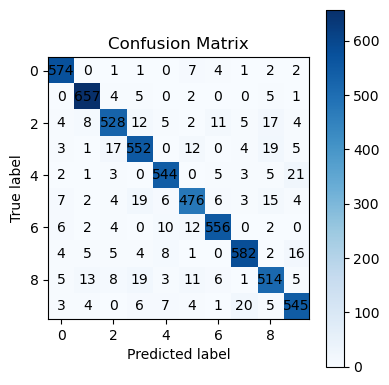

Saved: LogisticRegression_baseline (full)


In [26]:

#Train baseline model
baseline_model = LogisticRegression(max_iter=500, random_state=42)
baseline_model.fit(X_train, y_train)

y_train_pred = baseline_model.predict(X_train)
y_val_pred   = baseline_model.predict(X_val)

# Evaluation with evaluate_classification Function
train_metrics = evaluate_classification(
    y_train,
    y_train_pred,
    plot=False,
    title="Logistic Regression - Train"
)

val_metrics = evaluate_classification(
    y_val,
    y_val_pred,
    plot=True,
    title="Logistic Regression - Validation"
)

__Search for best parameters:__

In [42]:

param_grid = {
    "C": [0.05, 0.1, 0.2, 0.5],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)


grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

results_df = pd.DataFrame(grid.cv_results_)

pivot = results_df.pivot(
    index="param_C",
    columns="param_solver",
    values="mean_test_score"
)

print("\nScore matrix (rows=C, cols=solver):")
print(pivot.round(4))
best_lr = grid.best_estimator_


Best parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best CV score: 0.9207222222222223

Score matrix (rows=C, cols=solver):
param_solver   lbfgs
param_C             
0.05          0.9191
0.10          0.9207
0.20          0.9207
0.50          0.9201


In [46]:
best_model = grid.best_estimator_

print(best_model)

lr_results = kfold_cv(
    best_model,
    X_train,
    y_train,
    k=5,
    plot=False
  
)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

5-Fold CV Results
Accuracy : 0.9207
Precision: 0.9205
Recall   : 0.9207
F1       : 0.9205
Std      : 0.0031


## 2. KNN


===== KNN (k=5) - Train =====

Model Evaluation
Accuracy : 0.9815
Precision: 0.9816
Recall   : 0.9815
F1 score : 0.9815

===== KNN (k=5) - Validation =====

Model Evaluation
Accuracy : 0.9683
Precision: 0.9686
Recall   : 0.9683
F1 score : 0.9683


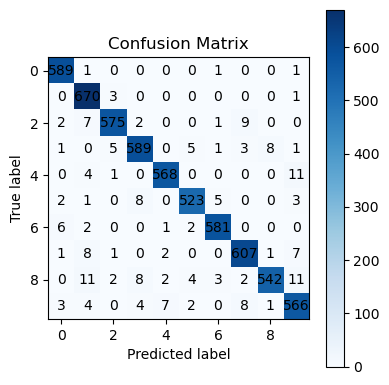

Saved: KNN_k5 (full)


In [30]:

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_train_pred = knn_model.predict(X_train)
y_val_pred   = knn_model.predict(X_val)

# Evaluation
train_metrics = evaluate_classification(
    y_train,
    y_train_pred,
    plot=False,
    title="KNN (k=5) - Train"
)

val_metrics = evaluate_classification(
    y_val,
    y_val_pred,
    plot=True,
    title="KNN (k=5) - Validation"
)


__Search for best parameters:__

In [48]:

param_grid = {
    "n_neighbors": [3, 5],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

# Results
print("Best parameters:", grid_knn.best_params_)
print("Best CV score:", grid_knn.best_score_)
 # Save on json file
results_df = pd.DataFrame(grid_knn.cv_results_)

pivot = results_df.pivot(
    index="param_n_neighbors",
    columns="param_weights",
    values="mean_test_score"
)

print("\nScore matrix (rows=n_neighbors, cols=weights):")
print(pivot.round(4))

# Best model
best_knn = grid_knn.best_estimator_

Best parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.9695

Score matrix (rows=n_neighbors, cols=weights):
param_weights      distance  uniform
param_n_neighbors                   
3                    0.9695   0.9680
5                    0.9693   0.9679


In [52]:
best_model = grid_knn.best_estimator_
print(best_model)

knn_results = kfold_cv(
    best_model,
    X_train,
    y_train,
    k=5,
    plot=False
)

KNeighborsClassifier(n_neighbors=3, weights='distance')

5-Fold CV Results
Accuracy : 0.9716
Precision: 0.9718
Recall   : 0.9716
F1       : 0.9716
Std      : 0.0012


## 3. Decision Tree 


===== Decision Tree (Baseline) - Train =====

Model Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000

===== Decision Tree (Baseline) - Validation =====

Model Evaluation
Accuracy : 0.8750
Precision: 0.8746
Recall   : 0.8750
F1 score : 0.8747


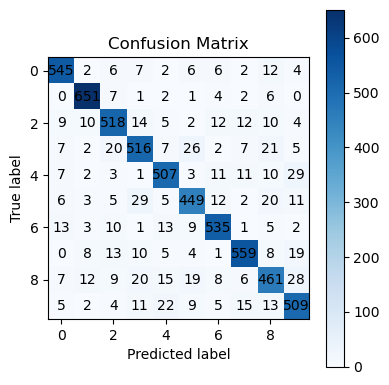

Saved: DecisionTree_Baseline (full)


In [34]:

dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predict
y_train_pred = dt_model.predict(X_train)
y_val_pred   = dt_model.predict(X_val)

# Evaluate
train_metrics = evaluate_classification(
    y_train,
    y_train_pred,
    plot=False,
    title="Decision Tree (Baseline) - Train"
)

val_metrics = evaluate_classification(
    y_val,
    y_val_pred,
    plot=True,
    title="Decision Tree (Baseline) - Validation"
)


__Search for best parameters__:

In [54]:

param_grid = {
    "max_depth": [5, 7, 10, 12], 
    "min_samples_split": [2, 5]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best parameters:", grid_dt.best_params_)
print("Best CV score:", grid_dt.best_score_)

results_df = pd.DataFrame(grid_dt.cv_results_)

pivot = results_df.pivot(
    index="param_max_depth",
    columns="param_min_samples_split",
    values="mean_test_score"
)

print("\nScore matrix:")
print(pivot.round(4))
best_dt = grid_dt.best_estimator_

Best parameters: {'max_depth': 12, 'min_samples_split': 2}
Best CV score: 0.859962962962963

Score matrix:
param_min_samples_split       2       5
param_max_depth                        
5                        0.6738  0.6738
7                        0.7762  0.7762
10                       0.8496  0.8487
12                       0.8600  0.8593


In [74]:
best_dt = grid_dt.best_estimator_

In [56]:
best_model = grid_dt.best_estimator_
print(best_model)

dt_results = kfold_cv(
    best_model,
    X_train,
    y_train,
    k=5,
    plot=False
)

DecisionTreeClassifier(max_depth=12, random_state=42)

5-Fold CV Results
Accuracy : 0.8651
Precision: 0.8649
Recall   : 0.8651
F1       : 0.8648
Std      : 0.0018


### __Best parameters found for all individual models__ : 

In [9]:
#### Logistic Regression
best_lr = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

###KNN
best_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance')

### Decision Tree
best_dt = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=2,
    random_state=42)


## 4. Ensemble Models

In [10]:

voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr), # best of Logistic regression
        ('knn', best_knn), # best of KNN
        ('dt', best_dt) # best of DecisionTree
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True


In [62]:
kfold_cv(
    voting_clf,
    X_train,
    y_train,
    k=5,
    plot=False
)



5-Fold CV Results
Accuracy : 0.9599
Precision: 0.9599
Recall   : 0.9599
F1       : 0.9599
Std      : 0.0010


{'model': "VotingClassifier(estimators=[('lr',\n                              LogisticRegression(C=0.1, max_iter=1000,\n                                                 random_state=42)),\n                             ('knn',\n                              KNeighborsClassifier(n_neighbors=3,\n                                                   weights='distance')),\n                             ('dt',\n                              DecisionTreeClassifier(max_depth=12,\n                                                     random_state=42))],\n                 voting='soft')",
 'k': 5,
 'per_fold': {'accuracy': [0.9610185185185185,
   0.9580555555555555,
   0.9607407407407408,
   0.9597222222222223,
   0.9601851851851851],
  'precision': [0.9609663317080406,
   0.9580043475833783,
   0.9607709670991301,
   0.9596781973853019,
   0.960203378568119],
  'recall': [0.9610185185185185,
   0.9580555555555555,
   0.9607407407407408,
   0.9597222222222223,
   0.9601851851851851],
  'f1': [0.96094

### Comparison between individual and soft model : 

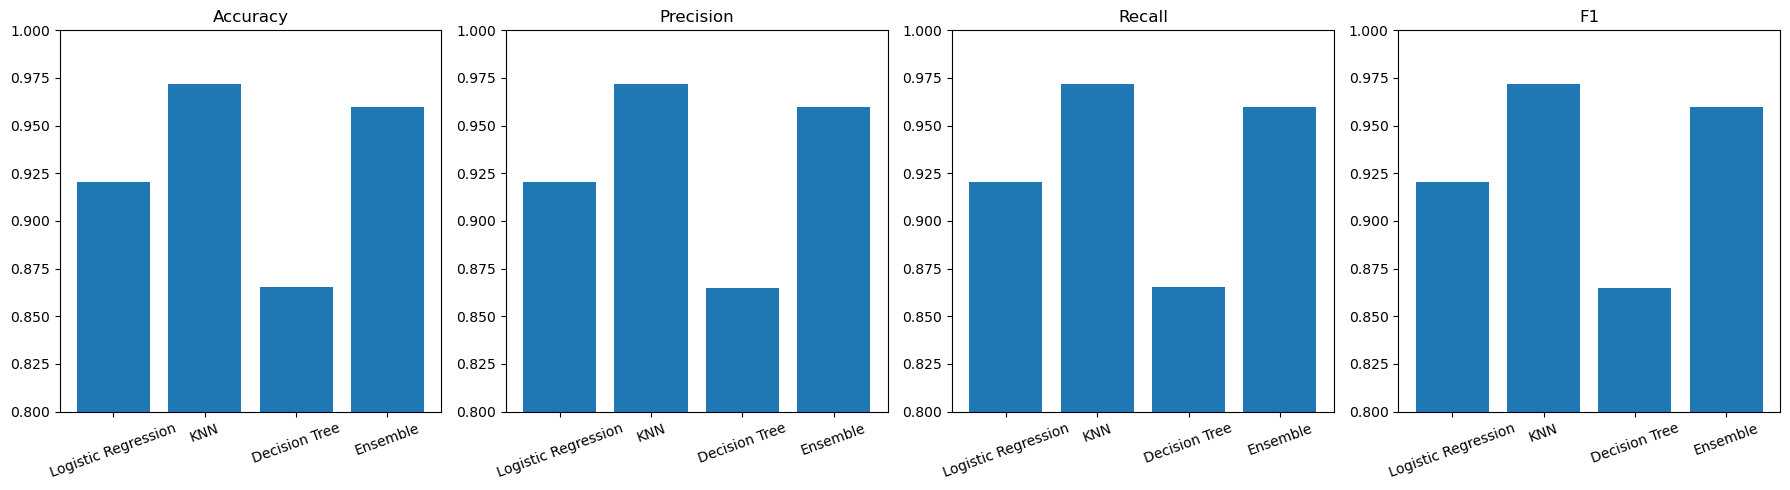

In [80]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.9207,
        "Precision": 0.9205,
        "Recall": 0.9207,
        "F1": 0.9205,
        "Std": 0.0031

        
    },
    {
        "Model": "KNN",
        "Accuracy": 0.9716,
        "Precision": 0.9718,
        "Recall": 0.9716,
        "F1": 0.9716,
        "Std": 0.001
        
    },
    {
        "Model": "Decision Tree", 

        "Accuracy": 0.8651,
        "Precision": 0.8649,
        "Recall": 0.8651,
        "F1": 0.8648,
        "Std": 0.0018
    },
    {
        "Model": "Ensemble",
        "Accuracy": 0.9599,
        "Precision": 0.9599,
        "Recall": 0.9599,
        "F1": 0.9599,
        "Std": 0.0010
    }
])



metrics = ["Accuracy", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(results["Model"], results[metric])
    axes[i].set_title(metric)
    axes[i].set_ylim(0.8, 1.0)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [84]:
results_sorted = results.sort_values(by="Accuracy", ascending=False)

results_sorted.style\
    .highlight_max(subset=["Accuracy","Precision","Recall","F1"], color="lightgreen")\
    .highlight_min(subset=["Std"], color="salmon")

,Model,Accuracy,Precision,Recall,F1,Std
1,KNN,0.971600,0.971800,0.971600,0.971600,0.001000
3,Ensemble,0.959900,0.959900,0.959900,0.959900,0.001000
0,Logistic Regression,0.920700,0.920500,0.920700,0.920500,0.003100
2,Decision Tree,0.865100,0.864900,0.865100,0.864800,0.001800


### Now work on TEST dataset 

In [76]:
models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "Ensemble": voting_clf
}

results = {}

for name, model in models.items():
    
    # predict on test set
    y_pred = model.predict(X_test)
    
    # metrics
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    }
    
    print("\n" + "="*50)
    print(name)
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.94      0.89      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.89      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


KNN
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.99      0.96      0.97      103

In [78]:
df_results = pd.DataFrame(results).T
print(df_results.sort_values(by="accuracy", ascending=False))

                     accuracy  precision    recall        f1
KNN                    0.9709   0.971090  0.970555  0.970726
Ensemble               0.9607   0.960510  0.960187  0.960296
Logistic Regression    0.9247   0.923782  0.923581  0.923552
Decision Tree          0.8717   0.870325  0.870027  0.869979


## 5 Final evaluation using Soft Voting : 

In [11]:
# =========================================================
# 2) PATHS
# =========================================================
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================================================
# 3) FINAL DATASETS
# =========================================================
X_train_final = np.concatenate([X_train, X_val], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)

# =========================================================
# 4) BEST MODELS
# =========================================================
best_lr = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

best_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

best_dt = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=2,
    random_state=42
)

# =========================================================
# 5) VOTING ENSEMBLE
# =========================================================
voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('knn', best_knn),
        ('dt', best_dt)
    ],
    voting='soft'
)

final_models = {
    "Voting Ensemble": voting_clf
}

# =========================================================
# 6) HELPERS
# =========================================================
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    return {
        "accuracy": float(acc),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "wrong_samples": int((1 - acc) * len(y_true))
    }

def evaluate_model(category, model, x_train, y_train, x_val, y_val, x_train_final, y_train_final, x_test, y_test):
    """
    1) Fit on train only -> evaluate on validation
    2) Fit on train+validation -> evaluate on test
    """
    model_val = clone(model)
    model_val.fit(x_train, y_train)

    y_train_pred = model_val.predict(x_train)
    y_val_pred = model_val.predict(x_val)

    train_metrics = compute_metrics(y_train, y_train_pred)
    val_metrics = compute_metrics(y_val, y_val_pred)

    model_test = clone(model)
    model_test.fit(x_train_final, y_train_final)

    y_train_final_pred = model_test.predict(x_train_final)
    y_test_pred = model_test.predict(x_test)

    train_final_metrics = compute_metrics(y_train_final, y_train_final_pred)
    test_metrics = compute_metrics(y_test, y_test_pred)

    results = {
        "category": category,
        "model_name": type(model).__name__,
        "best_params": {
            "estimators": {
                "logistic_regression": {
                    "C": 0.1,
                    "solver": "lbfgs",
                    "max_iter": 1000,
                    "random_state": 42
                },
                "knn": {
                    "n_neighbors": 3,
                    "weights": "distance"
                },
                "decision_tree": {
                    "max_depth": 12,
                    "min_samples_split": 2,
                    "random_state": 42
                }
            },
            "voting": "soft"
        },

        "data_info": {
            "n_train": int(len(y_train)),
            "n_validation": int(len(y_val)),
            "n_train_plus_validation": int(len(y_train_final)),
            "n_test": int(len(y_test))
        },

        "validation_experiment": {
            "train_metrics": train_metrics,
            "validation_metrics": val_metrics,
            "scores": {
                "train_accuracy": float(train_metrics["accuracy"]),
                "validation_accuracy": float(val_metrics["accuracy"])
            }
        },

        "final_test_experiment": {
            "train_plus_validation_metrics": train_final_metrics,
            "test_metrics": test_metrics,
            "scores": {
                "train_plus_validation_accuracy": float(train_final_metrics["accuracy"]),
                "test_accuracy": float(test_metrics["accuracy"])
            }
        }
    }

    return results

# =========================================================
# 7) RUN MODEL AND SAVE JSON
# =========================================================
all_results = {}

for category, model in final_models.items():
    results = evaluate_model(
        category=category,
        model=model,
        x_train=X_train,
        y_train=y_train,
        x_val=X_val,
        y_val=y_val,
        x_train_final=X_train_final,
        y_train_final=y_train_final,
        x_test=X_test,
        y_test=y_test
    )
    all_results[category] = results

with open("../results/03_ensemble.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Results saved in ../results/03_ensemble.json")

Results saved in ../results/03_ensemble.json
